# Bagging Classifier — Ensemble Learning

Bagging (Bootstrap Aggregating) is a parallel ensemble technique that trains multiple
instances of the same base estimator on different random subsets of the training data,
then aggregates their predictions by majority vote (classification) or averaging (regression).

**Core idea:** introduce variance in the training data so that individual models overfit
to slightly different patterns, and their errors partially cancel out when combined.

**Mathematical formulation:**

Given a dataset $\mathcal{D}$ of $N$ samples, Bagging draws $T$ bootstrap samples
$\mathcal{D}_1, \mathcal{D}_2, \ldots, \mathcal{D}_T$ (each of size $N$, sampled with replacement),
trains a base estimator $h_t$ on each, and produces the ensemble prediction:

$$\hat{y} = \text{argmax}_c \sum_{t=1}^{T} \mathbf{1}[h_t(x) = c]$$


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

## Dataset Generation

`make_classification` produces a synthetic binary classification dataset with controlled structure.

- `n_samples=1000` — total observations
- `n_features=10` — total input features
- `n_informative=3` — only 3 of the 10 features are genuinely predictive; the remaining 7 are noise or redundant


In [56]:
X, y = make_classification(n_samples=1000,n_features=10,n_informative=3)

print(f"Dataset shape  : {X.shape}")
print(f"Target range   : [{y.min():.2f}, {y.max():.2f}]")
print(f"Target mean    : {y.mean():.4f}")
print(f"Target std     : {y.std():.4f}")

Dataset shape  : (1000, 10)
Target range   : [0.00, 1.00]
Target mean    : 0.4980
Target std     : 0.5000


---
### Visualize the target distribution

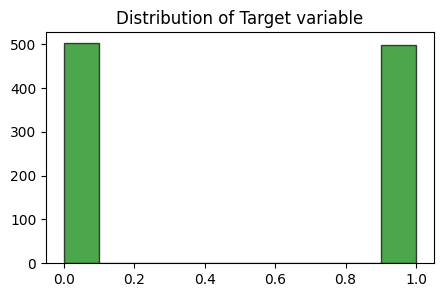

In [57]:
plt.figure(figsize=(5,3))
plt.hist(y, bins=10, edgecolor='black', alpha=0.7,color='green')
plt.title('Distribution of Target variable')
plt.show()

---
### Train-Test Split

Reserve 20% of the data as a **test set** — rows the model will never see during training. This lets us evaluate how well the model generalizes to new, unseen data.

- `test_size=0.2` means 80% of rows go to training, 20% to testing
- `random_state=42` fixes the random seed so results are reproducible

In [58]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

## Baseline: Decision Tree (No Bagging)

A single unpruned `DecisionTreeClassifier` serves as the baseline.

Decision trees are **high-variance** estimators: they tend to memorize training data
(low bias, high variance), which means small changes in training data can produce
very different trees. This makes them ideal base learners for Bagging.


Accuracy Score For Decision Tree :: 0.895


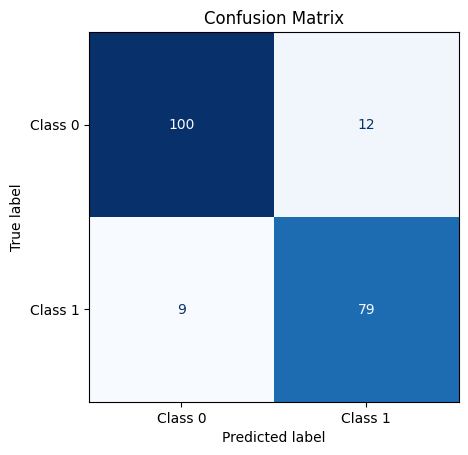

In [59]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)
print("Accuracy Score For Decision Tree ::",accuracy_score(y_test,y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

## Bagging with Decision Tree

`BaggingClassifier` wraps the decision tree and trains 500 independent estimators,
each on a bootstrap sample containing 25% of the training data (`max_samples=0.25`).

**Parameter notes:**

- `n_estimators=500` — number of base learners; more estimators generally reduce variance further, with diminishing returns
- `max_samples=0.25` — each bootstrap sample uses 200 out of 800 training points
- `max_features=1.0` — all 10 features are considered at each tree (no feature subsampling at this stage)
- `bootstrap=True` — sampling is with replacement; ~63.2% of unique samples appear in each bootstrap

**Why does this help?**

Each tree sees a different subset of training examples, causing each to overfit
to a different portion of the noise. When 500 such trees vote together, the noise
cancels and the signal is amplified.

Accuracy Score For Decision Tree with Bagging :: 0.9


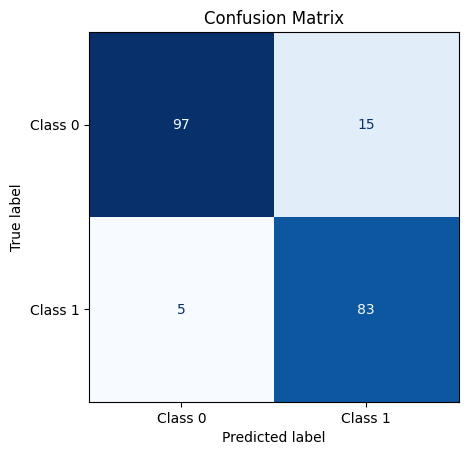

In [60]:
baggging = BaggingClassifier(
    estimator = decision_tree,
    n_estimators = 500,
    max_samples = 0.25,
    max_features = 1.0,
    bootstrap = True,
    random_state = 42
)

baggging.fit(X_train,y_train)

y_pred = baggging.predict(X_test)
print("Accuracy Score For Decision Tree with Bagging ::",accuracy_score(y_test,y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

## Baseline: SVC (No Bagging)

The Support Vector Classifier with default settings (`kernel='rbf'`, `C=1`) is a
**low-variance** estimator. SVMs are already robust to noise due to their maximum-margin
objective. The expectation is that Bagging provides minimal benefit over an already stable model.

Accuracy Score For Decision Tree :: 0.94


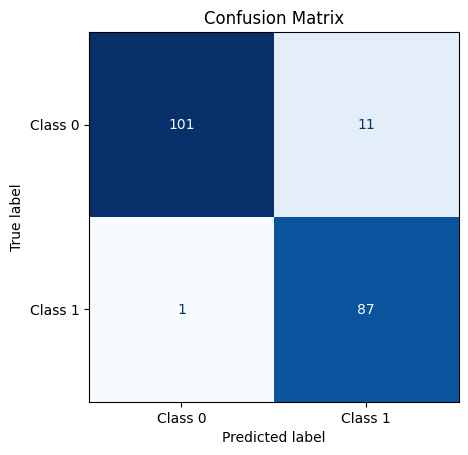

In [61]:
svc = SVC()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
print("Accuracy Score For Decision Tree ::",accuracy_score(y_test,y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

## Bagging with SVC

The same `BaggingClassifier` configuration is applied with `SVC()` as the base estimator.
The expected gain is marginal, since SVC is not a high-variance model.

> Note: Bagging with SVM is computationally expensive. The SVM itself is O(n²) to O(n³) in
training complexity. Using `max_samples=0.25` (200 samples per estimator) makes this feasible,
but 500 SVMs is still significantly heavier than 500 decision trees.

Accuracy Score For SVC with Bagging :: 0.91


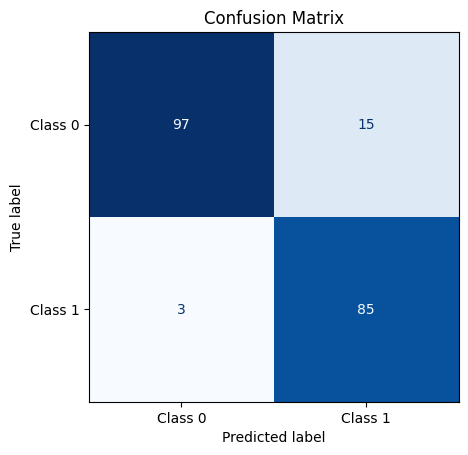

In [62]:
baggging = BaggingClassifier(
    estimator =svc ,
    n_estimators = 500,
    max_samples = 0.25,
    max_features = 1.0,
    bootstrap = True,
    random_state = 42
)
baggging.fit(X_train,y_train)
y_pred = baggging.predict(X_test)
print("Accuracy Score For SVC with Bagging ::",accuracy_score(y_test,y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()


## Bagging Variant: Random Subspace Method

In the Random Subspace method, diversity is introduced through **feature subsampling** rather
than sample subsampling.

**Configuration:**

- `bootstrap=False` — each estimator trains on the full training set (no sample subsampling)
- `bootstrap_features=True` — features are sampled with replacement
- `max_features=0.5` — each tree receives 5 of the 10 features randomly

**When is this useful?**

When the dataset has many features and you want each base learner to specialize on
a different feature subspace. This is particularly effective when features are noisy
or redundant, as in this dataset (7 of 10 features are non-informative).

Accuracy Score For Decision Tree with Bagging :: 0.9


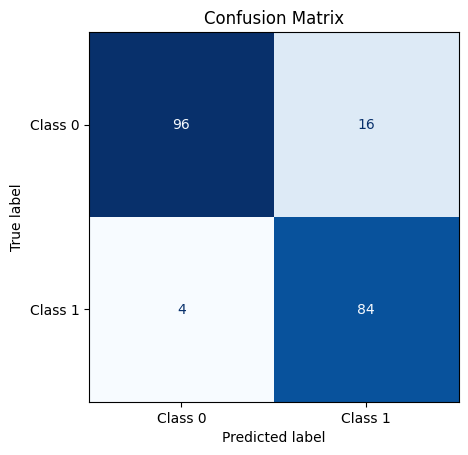

In [63]:
baggging = BaggingClassifier(
    estimator = decision_tree,
    n_estimators = 500,
    max_samples = 0.25,
    max_features = 0.5,
    bootstrap = False,
    bootstrap_features = True,
    random_state = 42
)
baggging.fit(X_train,y_train)
y_pred = baggging.predict(X_test)
print("Accuracy Score For Decision Tree with Bagging ::",accuracy_score(y_test,y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

## Bagging Variant: Random Patches

Random Patches combines both sample and feature subsampling, giving each base learner a
distinct "patch" of the data in both dimensions. This is the most aggressive diversity
strategy among the three variants.

**Configuration:**

- `bootstrap=True` — sample subsampling with replacement (70% of training samples)
- `bootstrap_features=True` — feature subsampling with replacement (60% of features)
- `oob_score=True` — enables Out-of-Bag evaluation (explained below)

**Out-of-Bag (OOB) Score:**

Since each estimator is trained on approximately 63.2% of unique samples (the rest are
"out-of-bag"), predictions can be made on OOB samples using only the trees that never
saw those samples during training. This provides an unbiased validation estimate
without requiring a separate validation set.

$$\text{OOB Score} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}\left[\hat{y}_i^{\text{oob}} = y_i\right]$$

Accuracy Score For Decision Tree with Bagging :: 0.925


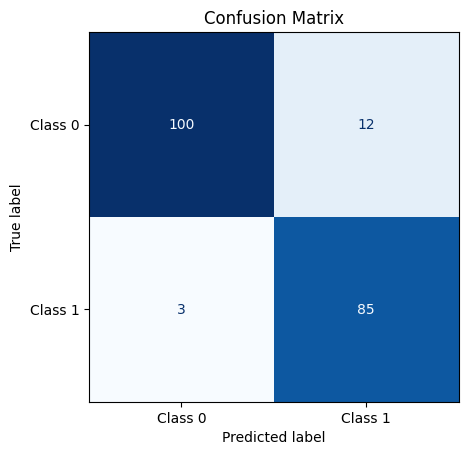

In [64]:
baggging = BaggingClassifier(
    estimator = decision_tree,
    n_estimators = 500,
    max_samples = 0.7,
    max_features = 0.6,
    bootstrap = True,
    oob_score = True,
    bootstrap_features = True,
    random_state = 42
)
baggging.fit(X_train,y_train)
y_pred = baggging.predict(X_test)
print("Accuracy Score For Decision Tree with Bagging ::",accuracy_score(y_test,y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

In [65]:
baggging.oob_score_

0.9025